In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('doctors_combined_data.csv')
df.head()


,Doctor Name,Education,Speciality,Experience,Chamber,Location,Concentration
0,Asst. Prof. Dr. Nurun Nahar Mohua,"MBBS,D-CARD,PHD",Cardiologist,16.0,Aalok Healthcare Ltd. | Mirpur 10,Dhaka-1216,"Bacterial Endocarditis,Cardiac Ablation,Cardia..."
1,Dr. Rezaul Alam Khan,"MBBS,CCD,MD (Medicine)",Medicine Specialist,23.0,Aalok Healthcare Ltd. | Mirpur 10,Dhaka-1216,"Adolescent Medicine,Aesthetic Medicine,Cardiac..."
2,Dr. Ummy Salma Munni,"MSc,MPhil,PhD (Nutrition & Food Science),INFS ...",Nutritionist,14.0,BRB Hospitals Limited,Dhaka-1205,"Diabetes Management,Diet Management,Food Aller..."
3,Dr. Mostafa Kamal Rouf,"MBBS,BCS (Health),FCPS (Medicine),PGT (Neurology)",Medicine Specialist,23.0,Aalok Healthcare Ltd. | Mirpur 10,Dhaka-1216,"Aesthetic Medicine,Alzheimer's Disease,Arthrit..."
4,Asst. Prof. Dr. Akhlak Ahmed,"MBBS (Dhaka),BCS (Health) FCPS (Medicine),MACP...",Medicine Specialist,19.0,Aalok Healthcare Ltd. | Mirpur 10,Dhaka-1216,"Adolescent Medicine,Aesthetic Medicine,Cardiac..."


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6520 entries, 0 to 6519
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Doctor Name    6520 non-null   object 
 1   Education      6520 non-null   object 
 2   Speciality     6520 non-null   object 
 3   Experience     6341 non-null   float64
 4   Chamber        6520 non-null   object 
 5   Location       6341 non-null   object 
 6   Concentration  6520 non-null   object 
dtypes: float64(1), object(6)
memory usage: 356.7+ KB


In [51]:
df.duplicated().sum()

np.int64(299)

In [52]:
df = df.drop_duplicates()

In [53]:
df.isnull().sum()

,0
Doctor Name,0
Education,0
Speciality,0
Experience,174
Chamber,0
Location,174
Concentration,0


In [54]:
df.describe()

,Experience
count,6047.000000
mean,19.944766
std,4.950893
min,2.000000
25%,16.000000
50%,19.000000
75%,23.000000
max,44.000000


In [55]:
cat_cols = df.select_dtypes(include = "object").columns
cat_cols

Index(['Doctor Name', 'Education', 'Speciality', 'Chamber', 'Location',
       'Concentration'],
      dtype='object')

In [56]:
num_cols = df.select_dtypes(exclude = "object").columns
num_cols

Index(['Experience'], dtype='object')

In [57]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in num_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [58]:
df.isnull().sum()

,0
Doctor Name,0
Education,0
Speciality,0
Experience,0
Chamber,0
Location,0
Concentration,0


In [59]:
df.head()

,Doctor Name,Education,Speciality,Experience,Chamber,Location,Concentration
0,Asst. Prof. Dr. Nurun Nahar Mohua,"MBBS,D-CARD,PHD",Cardiologist,16.0,Aalok Healthcare Ltd. | Mirpur 10,Dhaka-1216,"Bacterial Endocarditis,Cardiac Ablation,Cardia..."
1,Dr. Rezaul Alam Khan,"MBBS,CCD,MD (Medicine)",Medicine Specialist,23.0,Aalok Healthcare Ltd. | Mirpur 10,Dhaka-1216,"Adolescent Medicine,Aesthetic Medicine,Cardiac..."
2,Dr. Ummy Salma Munni,"MSc,MPhil,PhD (Nutrition & Food Science),INFS ...",Nutritionist,14.0,BRB Hospitals Limited,Dhaka-1205,"Diabetes Management,Diet Management,Food Aller..."
3,Dr. Mostafa Kamal Rouf,"MBBS,BCS (Health),FCPS (Medicine),PGT (Neurology)",Medicine Specialist,23.0,Aalok Healthcare Ltd. | Mirpur 10,Dhaka-1216,"Aesthetic Medicine,Alzheimer's Disease,Arthrit..."
4,Asst. Prof. Dr. Akhlak Ahmed,"MBBS (Dhaka),BCS (Health) FCPS (Medicine),MACP...",Medicine Specialist,19.0,Aalok Healthcare Ltd. | Mirpur 10,Dhaka-1216,"Adolescent Medicine,Aesthetic Medicine,Cardiac..."


In [60]:
df["Experience"].unique()

array([16., 23., 14., 19., 27., 24., 20., 15., 25., 21., 35., 10.,  5.,
       12., 40., 26.,  8., 13., 17., 30., 22., 11.,  6., 18., 37., 28.,
       31., 32., 29., 33.,  7.,  9.,  2.,  3., 44., 41.,  4., 34., 43.,
       42., 38., 36.])

In [61]:
df["Experience"] = df["Experience"].replace("?", np.nan)

In [62]:
df["Experience"].isnull().sum()

np.int64(0)

In [63]:
df["Experience"] = df["Experience"].fillna(pd.to_numeric(df["Experience"], errors="coerce").median())

In [64]:
df["Experience"] = pd.to_numeric(df["Experience"])

In [65]:
df["Experience"].dtype

dtype('float64')

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6221 entries, 0 to 6495
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Doctor Name    6221 non-null   object 
 1   Education      6221 non-null   object 
 2   Speciality     6221 non-null   object 
 3   Experience     6221 non-null   float64
 4   Chamber        6221 non-null   object 
 5   Location       6221 non-null   object 
 6   Concentration  6221 non-null   object 
dtypes: float64(1), object(6)
memory usage: 388.8+ KB


In [67]:
df = pd.read_csv('doctors_combined_data.csv')

# Re-apply necessary preprocessing steps to df
df = df.drop_duplicates()
df["Experience"] = df["Experience"].replace("", np.nan)
df["Experience"] = pd.to_numeric(df["Experience"], errors="coerce")
df["Experience"] = df["Experience"].fillna(df["Experience"].median())

# Redefine cat_cols and num_cols based on the clean df
cat_cols = df.select_dtypes(include = "object").columns
num_cols = df.select_dtypes(exclude = "object").columns

print("DataFrame reset and preprocessed.")
print(f"Corrected categorical columns: {list(cat_cols)}")
print(f"Corrected numerical columns: {list(num_cols)}")

DataFrame reset and preprocessed.
Corrected categorical columns: ['Doctor Name', 'Education', 'Speciality', 'Chamber', 'Location', 'Concentration']
Corrected numerical columns: ['Experience']


In [68]:
# Now, apply one-hot encoding to the correctly identified categorical columns
df_encoded = pd.get_dummies(df, columns = cat_cols, drop_first = True)
df = df_encoded # Update df with the encoded version
df.head()


,Experience,Doctor Name_Akhtarun Nahar Alo,Doctor Name_Antara rani pal,Doctor Name_Asso. Prof. DR. A K M Tariqul Hassan,Doctor Name_Asso. Prof. Dr. A. I. Zoardar,Doctor Name_Asso. Prof. Dr. ASM Moin Uddin,Doctor Name_Asso. Prof. Dr. Abdullah Al Faruk,Doctor Name_Asso. Prof. Dr. Afsana Rahman,Doctor Name_Asso. Prof. Dr. Dilip Kumar Debnath,Doctor Name_Asso. Prof. Dr. Fahima Afroze,...,"Concentration_bioidentical hormone therapies for men and women,Diabetes,Diabetes Induced Erectile Dysfunction,Goiter Treatment,Hyper / Hypo - Thyroid Treatment,Lactation Counselling,Gestational Diabetes Management,Diabetes in Children,Diabetes Management,Hormonal therapy,Hormone Dirtubances,Hormone testing,Growth Hormone Disorders,Hyperthyroidism,Hypothyroidism","Concentration_bioidentical hormone therapies for men and women,Diabetes,Diabetes Management,Goiter Treatment,Hyper / Hypo - Thyroid Treatment,Lactation Counselling,Lactation Support,Gestational Diabetes Management,Growth Hormone Disorders,Hormonal disturbances in women,Hyperthyroidism,Hypothyroidism,Diabetes in Cancers(immunocompromised)","Concentration_bioidentical hormone therapies for men and women,Diabetes,Diabetes Management,Goiter Treatment,Hyper / Hypo - Thyroid Treatment,Lactation,Lactation Counselling,Lactation Support,Diabetes in Cancers(immunocompromised),Diabetes in Children,Diabetes Management,Diabetes Mellitus","Concentration_bioidentical hormone therapies for men and women,Diabetes,Diabetes Management,Growth Hormone Disorders,Hormonal disturbances in women,Hormonal therapy,Hormone Dirtubances,Hormone testing,Hormone Therapy For Breast Cancer,Hyper / Hypo - Thyroid Treatment,Hyperthyroidism,Insulin Hormone,Parathyroid diseases,Diabetes Mellitus","Concentration_bioidentical hormone therapies for men and women,Diabetes,Diabetes in Cancers(immunocompromised),Growth Hormone Disorders,Hormonal disturbances in women,Hormonal therapy,Hormone Dirtubances,Hormone testing,Hyper / Hypo - Thyroid Treatment,Hyper / Hypo - Thyroidism Treatment,Hyperthyroidism,Cystic fibrosis-related diabetes","Concentration_bioidentical hormone therapies for men and women,Diabetes,Diabetes in Children,Diabetes Management,Disorders in the hormone-producing adrenal glands and pituitary glands,Growth & Development,Growth Hormone Disorders,Hyper / Hypo - Thyroid Treatment,Hypertrophic Cardiomyopathy,Thyroid Disease Management","Concentration_bioidentical hormone therapies for men and women,Diabetes,Growth Hormone Disorders,Hormonal disturbances in women,Hormonal therapy,Hormone Dirtubances,Hormone testing,Hyper / Hypo - Thyroid Treatment,Hyper / Hypo - Thyroidism Treatment,Hyperthyroidism,Insulin Hormone,Parathyroid diseases,Parathyroid disorders,Thyroid Diseases,Thyroid Disorders in Diabetes,Thyroid nodule,Depression and Anxiety in Diabetes","Concentration_bioidentical hormone therapies for men and women,Growth & Development,Growth Hormone Disorders,Hormonal therapy,Hormone Dirtubances,Hyper / Hypo - Thyroid Treatment,Parathyroid diseases,Parathyroid diseases,Parathyroid disorders,Parathyroid Hormone","Concentration_eczema,Atopic Dermatitis Treatment,Acne Problems,Alopecia Areata,Dermatitis Treatment,Herpes zoster (shingles),Rosacea,Skin Allergies,Vitiligo,WARTS,Psoriasis Treatment,Impetigo,treatment for ringworm","Concentration_laparoscopy surgery,Laproscopic hernia surgery,Laparoscopic Cholecystectomy,Pediatric Surgery,Pediatric Urology,Neonatal Surgery,Hydrocele Treatment (Surgical),Circumcision,Hirschsprung's disease,Anorectal Malformations,Hypospadias treatment,Abdominal surgery,Abdominal Pain Treatment,Abdominal Trauma & Perforation,Abdominoperineal Resection (Pediatric)"
0,16.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,23.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,14.0,False,False,False,False,False,False,False,False,False,...,False,False,False,Fa

In [69]:
print(f"Shape of the encoded DataFrame: {df.shape}")
display(df.head())

Shape of the encoded DataFrame: (6221, 14131)


,Experience,Doctor Name_Akhtarun Nahar Alo,Doctor Name_Antara rani pal,Doctor Name_Asso. Prof. DR. A K M Tariqul Hassan,Doctor Name_Asso. Prof. Dr. A. I. Zoardar,Doctor Name_Asso. Prof. Dr. ASM Moin Uddin,Doctor Name_Asso. Prof. Dr. Abdullah Al Faruk,Doctor Name_Asso. Prof. Dr. Afsana Rahman,Doctor Name_Asso. Prof. Dr. Dilip Kumar Debnath,Doctor Name_Asso. Prof. Dr. Fahima Afroze,...,"Concentration_bioidentical hormone therapies for men and women,Diabetes,Diabetes Induced Erectile Dysfunction,Goiter Treatment,Hyper / Hypo - Thyroid Treatment,Lactation Counselling,Gestational Diabetes Management,Diabetes in Children,Diabetes Management,Hormonal therapy,Hormone Dirtubances,Hormone testing,Growth Hormone Disorders,Hyperthyroidism,Hypothyroidism","Concentration_bioidentical hormone therapies for men and women,Diabetes,Diabetes Management,Goiter Treatment,Hyper / Hypo - Thyroid Treatment,Lactation Counselling,Lactation Support,Gestational Diabetes Management,Growth Hormone Disorders,Hormonal disturbances in women,Hyperthyroidism,Hypothyroidism,Diabetes in Cancers(immunocompromised)","Concentration_bioidentical hormone therapies for men and women,Diabetes,Diabetes Management,Goiter Treatment,Hyper / Hypo - Thyroid Treatment,Lactation,Lactation Counselling,Lactation Support,Diabetes in Cancers(immunocompromised),Diabetes in Children,Diabetes Management,Diabetes Mellitus","Concentration_bioidentical hormone therapies for men and women,Diabetes,Diabetes Management,Growth Hormone Disorders,Hormonal disturbances in women,Hormonal therapy,Hormone Dirtubances,Hormone testing,Hormone Therapy For Breast Cancer,Hyper / Hypo - Thyroid Treatment,Hyperthyroidism,Insulin Hormone,Parathyroid diseases,Diabetes Mellitus","Concentration_bioidentical hormone therapies for men and women,Diabetes,Diabetes in Cancers(immunocompromised),Growth Hormone Disorders,Hormonal disturbances in women,Hormonal therapy,Hormone Dirtubances,Hormone testing,Hyper / Hypo - Thyroid Treatment,Hyper / Hypo - Thyroidism Treatment,Hyperthyroidism,Cystic fibrosis-related diabetes","Concentration_bioidentical hormone therapies for men and women,Diabetes,Diabetes in Children,Diabetes Management,Disorders in the hormone-producing adrenal glands and pituitary glands,Growth & Development,Growth Hormone Disorders,Hyper / Hypo - Thyroid Treatment,Hypertrophic Cardiomyopathy,Thyroid Disease Management","Concentration_bioidentical hormone therapies for men and women,Diabetes,Growth Hormone Disorders,Hormonal disturbances in women,Hormonal therapy,Hormone Dirtubances,Hormone testing,Hyper / Hypo - Thyroid Treatment,Hyper / Hypo - Thyroidism Treatment,Hyperthyroidism,Insulin Hormone,Parathyroid diseases,Parathyroid disorders,Thyroid Diseases,Thyroid Disorders in Diabetes,Thyroid nodule,Depression and Anxiety in Diabetes","Concentration_bioidentical hormone therapies for men and women,Growth & Development,Growth Hormone Disorders,Hormonal therapy,Hormone Dirtubances,Hyper / Hypo - Thyroid Treatment,Parathyroid diseases,Parathyroid diseases,Parathyroid disorders,Parathyroid Hormone","Concentration_eczema,Atopic Dermatitis Treatment,Acne Problems,Alopecia Areata,Dermatitis Treatment,Herpes zoster (shingles),Rosacea,Skin Allergies,Vitiligo,WARTS,Psoriasis Treatment,Impetigo,treatment for ringworm","Concentration_laparoscopy surgery,Laproscopic hernia surgery,Laparoscopic Cholecystectomy,Pediatric Surgery,Pediatric Urology,Neonatal Surgery,Hydrocele Treatment (Surgical),Circumcision,Hirschsprung's disease,Anorectal Malformations,Hypospadias treatment,Abdominal surgery,Abdominal Pain Treatment,Abdominal Trauma & Perforation,Abdominoperineal Resection (Pediatric)"
0,16.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,23.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,14.0,False,False,False,False,False,False,False,False,False,...,False,False,False,Fa

In [70]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
  if col in df.columns:
    df[col] = le.fit_transform(df[col])
  else:
    print(f"Column '{col}' not found in DataFrame, skipping Label Encoding.")

Column 'Doctor Name' not found in DataFrame, skipping Label Encoding.
Column 'Education' not found in DataFrame, skipping Label Encoding.
Column 'Speciality' not found in DataFrame, skipping Label Encoding.
Column 'Chamber' not found in DataFrame, skipping Label Encoding.
Column 'Location' not found in DataFrame, skipping Label Encoding.
Column 'Concentration' not found in DataFrame, skipping Label Encoding.


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6221 entries, 0 to 6495
Columns: 14131 entries, Experience to Concentration_laparoscopy surgery,Laproscopic hernia surgery,Laparoscopic Cholecystectomy,Pediatric Surgery,Pediatric Urology,Neonatal Surgery,Hydrocele Treatment (Surgical),Circumcision,Hirschsprung's disease,Anorectal Malformations,Hypospadias treatment,Abdominal surgery,Abdominal Pain Treatment,Abdominal Trauma & Perforation,Abdominoperineal Resection (Pediatric)
dtypes: bool(14130), float64(1)
memory usage: 83.9 MB


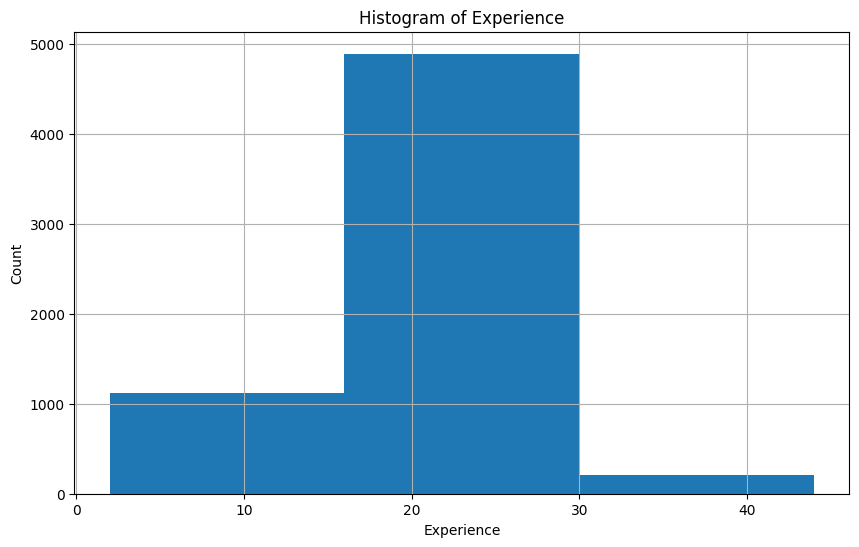

In [72]:
import matplotlib.pyplot as plt

# univariate Analysis
plt.figure(figsize=(10,6))
df["Experience"].hist(bins = 3)
plt.xlabel("Experience")
plt.ylabel("Count")
plt.title("Histogram of Experience")
plt.show()

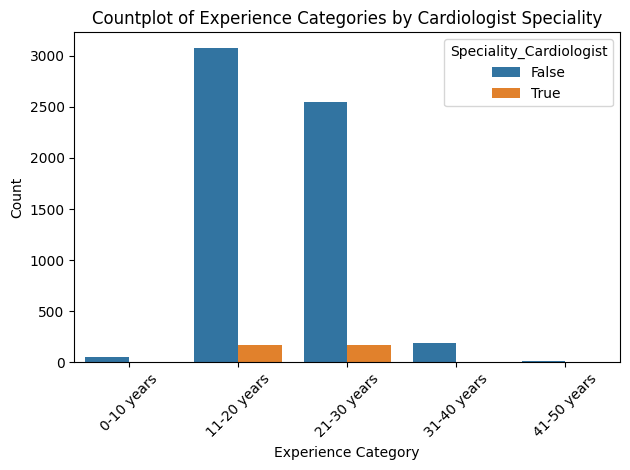

In [73]:
# Bivariate analysis

# Define bins and labels for Experience
bins = [0, 10, 20, 30, 40, 50]
labels = ['0-10 years', '11-20 years', '21-30 years', '31-40 years', '41-50 years']

# Create 'Experience_Category' directly in df
df['Experience_Category'] = pd.cut(df['Experience'], bins=bins, labels=labels, right=False)

sns.countplot(x="Experience_Category", hue="Speciality_Cardiologist", data=df)
plt.xlabel("Experience Category")
plt.ylabel("Count")
plt.title("Countplot of Experience Categories by Cardiologist Speciality")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Drop the temporary column if not needed for further analysis
df = df.drop(columns=['Experience_Category'])

In [74]:
# Define bins and labels for Experience_Category
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, float('inf')] # Using float('inf') to ensure the last bin is always the largest and monotonically increasing
labels = ['0-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45+']

# Create 'Experience_Category' as an ordinal feature
df['Experience_Category'] = pd.cut(df['Experience'], bins=bins, labels=labels, right=False, include_lowest=True)

display(df[['Experience', 'Experience_Category']].head())

,Experience,Experience_Category
0,16.0,15-19
1,23.0,20-24
2,14.0,10-14
3,23.0,20-24
4,19.0,15-19


In [75]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Experience_Category_Encoded'] = le.fit_transform(df['Experience_Category'])

print("Label Encoded 'Experience_Category':")
display(df[['Experience_Category', 'Experience_Category_Encoded']].head())

Label Encoded 'Experience_Category':


,Experience_Category,Experience_Category_Encoded
0,15-19,2
1,20-24,3
2,10-14,1
3,20-24,3
4,15-19,2


In [76]:
# The nominal columns for One-Hot Encoding have already been processed in a previous step.
# This cell will now focus on dropping redundant and identifier columns to finalize the DataFrame for modeling.

# Create a list of columns to drop
columns_to_drop = ['Experience_Category'] # Drop the original categorical version of experience

# Identify columns that start with 'Doctor Name_' and add them to the list to drop
# This is to remove the one-hot encoded versions of 'Doctor Name' as it's an identifier.
doctor_name_ohe_cols = [col for col in df.columns if col.startswith('Doctor Name_')]
columns_to_drop.extend(doctor_name_ohe_cols)

# Drop the identified columns from the DataFrame
df_final = df.drop(columns=columns_to_drop, errors='ignore')

# The final DataFrame `df_final` now contains the numerical 'Experience', the Label Encoded 'Experience_Category_Encoded',
# and the One-Hot Encoded nominal features (Education, Speciality, Chamber, Location, Concentration),
# with 'Doctor Name' and the original 'Experience_Category' removed.

print(f"\nShape of the DataFrame after dropping redundant and identifier columns: {df_final.shape}")
display(df_final.head())

# Update df to df_final for subsequent steps if needed
df = df_final


Shape of the DataFrame after dropping redundant and identifier columns: (6221, 8219)


,Experience,"Education_B. Sc,M.Sc. (Food and Nutrition)","Education_B.S.C,M.S.C,(Food & Nutrition),internship in Clinical Nutrition (BIRDEM),C.N.D (MIRDEM)","Education_B.Sc & M.Sc,Food & Nutrition","Education_B.Sc (Food & Nutrition Science),MSc (Food & Nutrition Science),ALPIDE HUMAN SCIENCE (DHAKA UNIVERSITY)","Education_B.Sc (Food & Nutrition),M.Sc (Food & Nutrition),MPH (Public Health Nutrition)","Education_B.Sc (Food & Nutrition),MPH,M.Sc","Education_B.Sc (Hon's),M.Sc (Nutrition and Food Science),CND (BIRDEM)","Education_B.Sc (Hons),M.Sc (Food & Nutrition Science)","Education_B.Sc (Hons),M.Sc (Food & Nutrition),MPH",...,"Concentration_bioidentical hormone therapies for men and women,Diabetes,Diabetes Management,Goiter Treatment,Hyper / Hypo - Thyroid Treatment,Lactation Counselling,Lactation Support,Gestational Diabetes Management,Growth Hormone Disorders,Hormonal disturbances in women,Hyperthyroidism,Hypothyroidism,Diabetes in Cancers(immunocompromised)","Concentration_bioidentical hormone therapies for men and women,Diabetes,Diabetes Management,Goiter Treatment,Hyper / Hypo - Thyroid Treatment,Lactation,Lactation Counselling,Lactation Support,Diabetes in Cancers(immunocompromised),Diabetes in Children,Diabetes Management,Diabetes Mellitus","Concentration_bioidentical hormone therapies for men and women,Diabetes,Diabetes Management,Growth Hormone Disorders,Hormonal disturbances in women,Hormonal therapy,Hormone Dirtubances,Hormone testing,Hormone Therapy For Breast Cancer,Hyper / Hypo - Thyroid Treatment,Hyperthyroidism,Insulin Hormone,Parathyroid diseases,Diabetes Mellitus","Concentration_bioidentical hormone therapies for men and women,Diabetes,Diabetes in Cancers(immunocompromised),Growth Hormone Disorders,Hormonal disturbances in women,Hormonal therapy,Hormone Dirtubances,Hormone testing,Hyper / Hypo - Thyroid Treatment,Hyper / Hypo - Thyroidism Treatment,Hyperthyroidism,Cystic fibrosis-related diabetes","Concentration_bioidentical hormone therapies for men and women,Diabetes,Diabetes in Children,Diabetes Management,Disorders in the hormone-producing adrenal glands and pituitary glands,Growth & Development,Growth Hormone Disorders,Hyper / Hypo - Thyroid Treatment,Hypertrophic Cardiomyopathy,Thyroid Disease Management","Concentration_bioidentical hormone therapies for men and women,Diabetes,Growth Hormone Disorders,Hormonal disturbances in women,Hormonal therapy,Hormone Dirtubances,Hormone testing,Hyper / Hypo - Thyroid Treatment,Hyper / Hypo - Thyroidism Treatment,Hyperthyroidism,Insulin Hormone,Parathyroid diseases,Parathyroid disorders,Thyroid Diseases,Thyroid Disorders in Diabetes,Thyroid nodule,Depression and Anxiety in Diabetes","Concentration_bioidentical hormone therapies for men and women,Growth & Development,Growth Hormone Disorders,Hormonal therapy,Hormone Dirtubances,Hyper / Hypo - Thyroid Treatment,Parathyroid diseases,Parathyroid diseases,Parathyroid disorders,Parathyroid Hormone","Concentration_eczema,Atopic Dermatitis Treatment,Acne Problems,Alopecia Areata,Dermatitis Treatment,Herpes zoster (shingles),Rosacea,Skin Allergies,Vitiligo,WARTS,Psoriasis Treatment,Impetigo,treatment for ringworm","Concentration_laparoscopy surgery,Laproscopic hernia surgery,Laparoscopic Cholecystectomy,Pediatric Surgery,Pediatric Urology,Neonatal Surgery,Hydrocele Treatment (Surgical),Circumcision,Hirschsprung's disease,Anorectal Malformations,Hypospadias treatment,Abdominal surgery,Abdominal Pain Treatment,Abdominal Trauma & Perforation,Abdominoperineal Resection (Pediatric)",Experience_Category_Encoded
0,16.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,2
1,23.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,3
2,14.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
3,23.0,False,False,False,False,False,False,False,False,False,...,